<a href="https://colab.research.google.com/github/Surhan-Memon/Ames_Housing_Dataset/blob/main/Ames_Housing_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/AmesHousing.csv')

In [ ]:
df.corr(numeric_only=True)['SalePrice'].sort_values()

,SalePrice
PID,-0.246521
Enclosed Porch,-0.128787
Kitchen AbvGr,-0.119814
Overall Cond,-0.101697
MS SubClass,-0.085092
Low Qual Fin SF,-0.037660
Bsmt Half Bath,-0.035835
Order,-0.031408
Yr Sold,-0.030569
Misc Val,-0.015691


<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

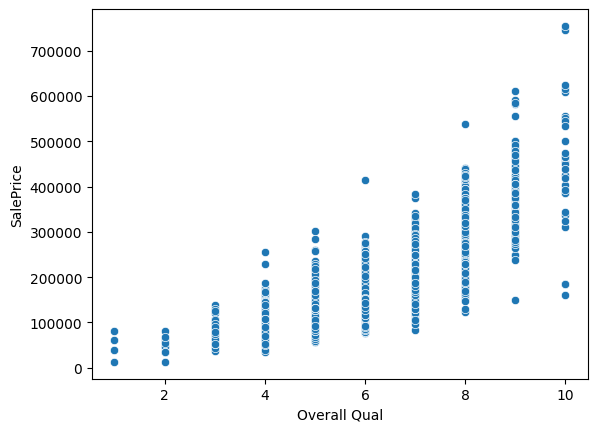

In [ ]:
sns.scatterplot(x='Overall Qual', y='SalePrice', data=df)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

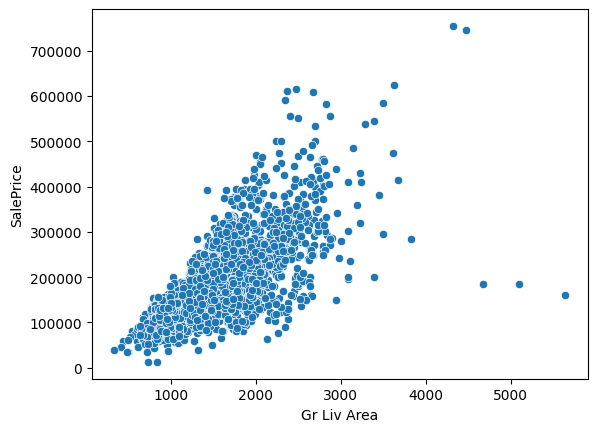

In [ ]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

In [ ]:
df[(df['Overall Qual']>8) & (df['SalePrice']<200000)]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,1183,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,1499,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,2181,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,2182,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [ ]:
drop_ind = df[(df['Gr Liv Area']>4000) & (df['SalePrice']<400000)].index

In [ ]:
df = df.drop(drop_ind,axis=0)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

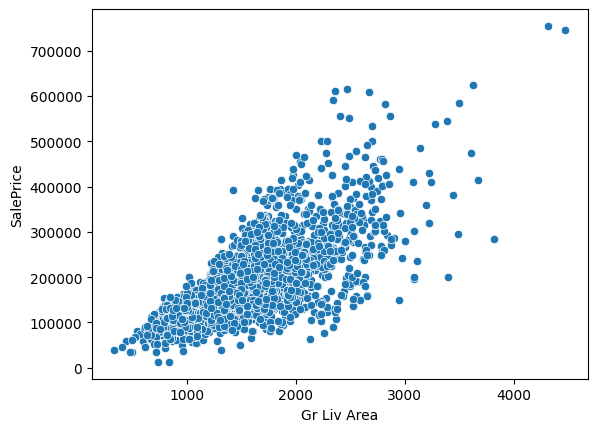

In [ ]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

In [ ]:
df.to_csv('Ames_housing_outliers_removed')

In [ ]:
df = pd.read_csv('/content/Ames_housing_outliers_removed')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2927 entries, 0 to 2926
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2927 non-null   int64  
 1   Order            2927 non-null   int64  
 2   PID              2927 non-null   int64  
 3   MS SubClass      2927 non-null   int64  
 4   MS Zoning        2927 non-null   object 
 5   Lot Frontage     2437 non-null   float64
 6   Lot Area         2927 non-null   int64  
 7   Street           2927 non-null   object 
 8   Alley            198 non-null    object 
 9   Lot Shape        2927 non-null   object 
 10  Land Contour     2927 non-null   object 
 11  Utilities        2927 non-null   object 
 12  Lot Config       2927 non-null   object 
 13  Land Slope       2927 non-null   object 
 14  Neighborhood     2927 non-null   object 
 15  Condition 1      2927 non-null   object 
 16  Condition 2      2927 non-null   object 
 17  Bldg Type     

In [ ]:
df.head()

,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df = df.drop('PID', axis=1)

In [ ]:
len(df.columns)

82

In [ ]:
100 * df.isnull().sum() / len(df)

,0
Unnamed: 0,0.00000
Order,0.00000
MS SubClass,0.00000
MS Zoning,0.00000
Lot Frontage,16.74069
...,...
Mo Sold,0.00000
Yr Sold,0.00000
Sale Type,0.00000
Sale Condition,0.00000


In [ ]:
def percent_missing(df):
  percent_nan = 100 * df.isnull().sum() / len(df)
  percent_nan = percent_nan[percent_nan > 0].sort_values()

  return percent_nan

In [ ]:
percent_nan = percent_missing(df)

In [ ]:
percent_nan

,0
Total Bsmt SF,0.034165
Bsmt Unf SF,0.034165
BsmtFin SF 2,0.034165
Electrical,0.034165
BsmtFin SF 1,0.034165
Garage Area,0.034165
Garage Cars,0.034165
Bsmt Full Bath,0.068329
Bsmt Half Bath,0.068329
Mas Vnr Area,0.785787


(0.0, 1.0)

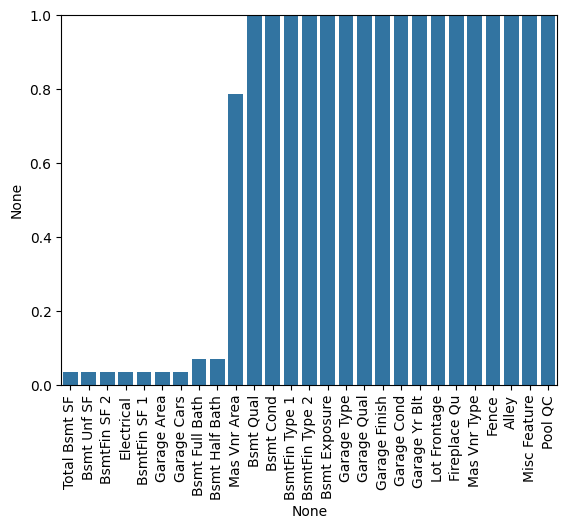

In [ ]:
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [ ]:
percent_nan[percent_nan < 1]

,0
Total Bsmt SF,0.034165
Bsmt Unf SF,0.034165
BsmtFin SF 2,0.034165
Electrical,0.034165
BsmtFin SF 1,0.034165
Garage Area,0.034165
Garage Cars,0.034165
Bsmt Full Bath,0.068329
Bsmt Half Bath,0.068329
Mas Vnr Area,0.785787


In [ ]:
100/len(df)

0.0341646737273659

In [ ]:
df[df['Electrical'].isnull()]['Garage Area']

,Garage Area
1576,400.0


In [ ]:
df[df['Bsmt Half Bath'].isnull()]

,Unnamed: 0,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,1341,1342,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,1497,1498,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [ ]:
df = df.dropna(axis=0, subset = ['Electrical', 'Garage Cars'])

In [ ]:
percent_nan = percent_missing(df)

In [ ]:
percent_nan[percent_nan < 1]

,0
Total Bsmt SF,0.034188
Bsmt Unf SF,0.034188
BsmtFin SF 2,0.034188
BsmtFin SF 1,0.034188
Bsmt Full Bath,0.068376
Bsmt Half Bath,0.068376
Mas Vnr Area,0.786325


(0.0, 1.0)

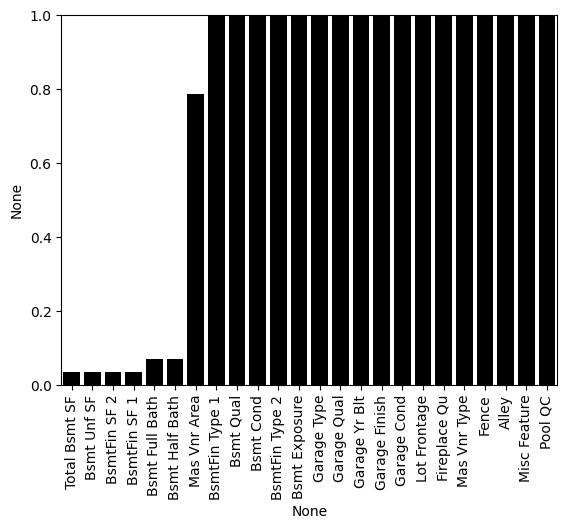

In [ ]:
sns.barplot(x=percent_nan.index, y=percent_nan, color='black')
plt.xticks(rotation=90)
plt.ylim(0,1)

In [ ]:
df[df['Bsmt Unf SF'].isnull()]

,Unnamed: 0,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,1341,1342,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [ ]:
df[df['Bsmt Full Bath'].isnull()]

,Unnamed: 0,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,1341,1342,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,1497,1498,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [ ]:
#BSMT Numeric Column --> Fillna 0
bsmt_num_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

#BSMT String Columns
bsmt_str_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
df[bsmt_str_cols] = df[bsmt_str_cols].fillna('None')

In [ ]:
df[df['Bsmt Full Bath'].isnull()]

,Unnamed: 0,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


(0.0, 1.0)

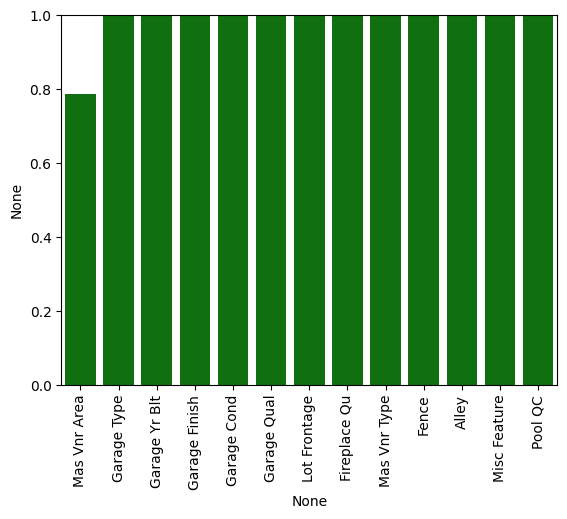

In [ ]:
percent_nan = percent_missing(df)

sns.barplot(x=percent_nan.index, y=percent_nan, color='green')
plt.xticks(rotation=90)
plt.ylim(0,1)

In [ ]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna('None')

In [ ]:
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [ ]:
percent_nan = percent_missing(df)

(0.0, 1.0)

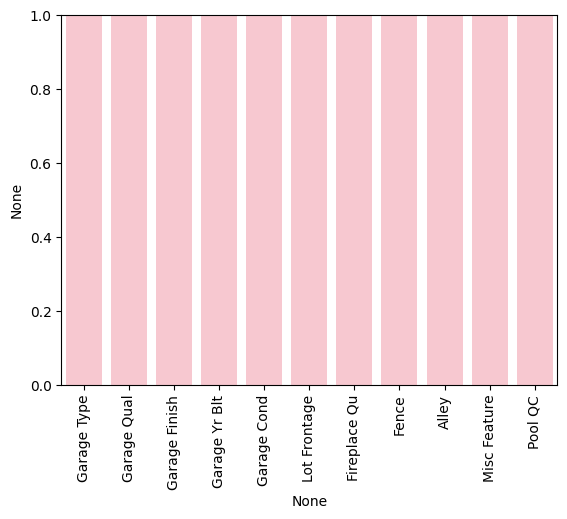

In [ ]:
sns.barplot(x=percent_nan.index, y=percent_nan, color='pink')
plt.xticks(rotation=90)
plt.ylim(0,1)

In [ ]:
gar_str_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']

In [ ]:
df[gar_str_cols] = df[gar_str_cols].fillna('None')

In [ ]:
percent_nan = percent_missing(df)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Garage Yr Blt'),
  Text(1, 0, 'Lot Frontage'),
  Text(2, 0, 'Fireplace Qu'),
  Text(3, 0, 'Fence'),
  Text(4, 0, 'Alley'),
  Text(5, 0, 'Misc Feature'),
  Text(6, 0, 'Pool QC')])

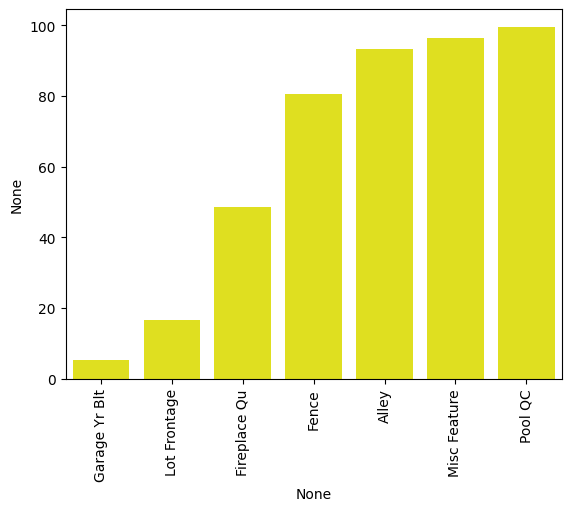

In [ ]:
sns.barplot(x=percent_nan.index, y=percent_nan, color='yellow')
plt.xticks(rotation=90)

In [ ]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [ ]:
df = df.drop(['Pool QC','Misc Feature', 'Alley', 'Fence'], axis=1)

In [ ]:
percent_nan = percent_missing(df)

([0, 1], [Text(0, 0, 'Lot Frontage'), Text(1, 0, 'Fireplace Qu')])

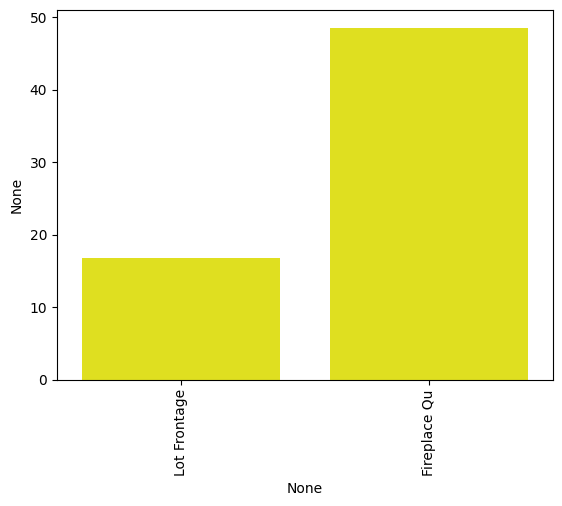

In [ ]:
sns.barplot(x=percent_nan.index, y=percent_nan, color='yellow')
plt.xticks(rotation=90)

In [ ]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

In [ ]:
df['Lot Frontage']

,Lot Frontage
0,141.0
1,80.0
2,81.0
3,93.0
4,74.0
...,...
2922,37.0
2923,NaN
2924,62.0
2925,77.0


<Axes: xlabel='Lot Frontage', ylabel='Neighborhood'>

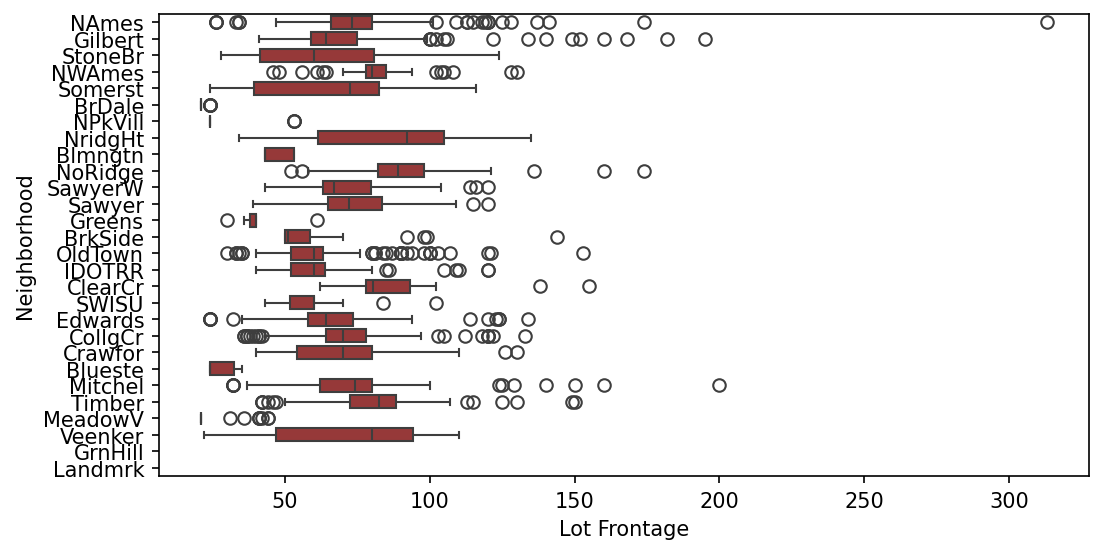

In [ ]:
plt.figure(figsize=(8,4), dpi=150)
sns.boxplot(x='Lot Frontage', y='Neighborhood', data=df, orient='h', color='brown')

In [ ]:
df.groupby('Neighborhood')['Lot Frontage'].mean()

,Lot Frontage
Neighborhood,
Blmngtn,46.900000
Blueste,27.300000
BrDale,21.500000
BrkSide,55.789474
ClearCr,88.150000
CollgCr,71.336364
Crawfor,69.951807
Edwards,64.794286
Gilbert,74.207207


In [ ]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda value: value.fillna(value.mean()))

In [ ]:
#df.groupby('Neighborhood')['Lot Frontage']

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Order,0
MS SubClass,0
MS Zoning,0
Lot Frontage,3
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Order,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
percent_nan = percent_missing(df)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

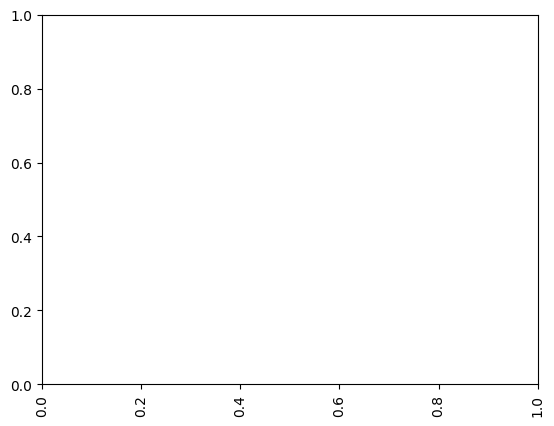

In [ ]:
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90)

In [ ]:
df.to_csv('Ames_housing_missing_values')

In [ ]:
df = pd.read_csv('/content/Ames_housing_missing_values')

In [ ]:
df.isnull().sum() > 0

,0
Unnamed: 0.1,False
Unnamed: 0,False
Order,False
MS SubClass,False
MS Zoning,False
...,...
Mo Sold,False
Yr Sold,False
Sale Type,False
Sale Condition,False


In [ ]:
df['MS SubClass'] = df['MS SubClass'].apply(str)

In [ ]:
direction = pd.Series(['Up', 'Up', 'Down'])

In [ ]:
direction

,0
0,Up
1,Up
2,Down


In [ ]:
pd.get_dummies(direction, drop_first = True)

,Up
0,True
1,True
2,False


In [ ]:
df.select_dtypes(include='object')

,MS SubClass,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,TA,Typ,Gd,Attchd,Fin,TA,TA,P,WD,Normal
1,20,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
3,20,RL,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
4,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,80,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,TA,Typ,NaN,Detchd,Unf,TA,TA,Y,WD,Normal
2921,20,RL,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2922,85,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,TA,Typ,NaN,NaN,NaN,NaN,NaN,Y,WD,Normal
2923,20,RL,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [ ]:
#df.info()

my_object_df = df.select_dtypes(include='object')

In [ ]:
my_numeric_df = df.select_dtypes(exclude='object')

In [ ]:
#my_numeric_df

In [ ]:
df_object_dummies = pd.get_dummies(my_object_df, drop_first=True)

In [ ]:
df_object_dummies

,MS SubClass_150,MS SubClass_160,MS SubClass_180,MS SubClass_190,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2921,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2922,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2923,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
final_df = pd.concat([my_numeric_df, df_object_dummies], axis=1)

In [ ]:
final_df.corr()['SalePrice'].sort_values()

,SalePrice
Exter Qual_TA,-0.591459
Kitchen Qual_TA,-0.527461
Bsmt Qual_TA,-0.453022
Garage Finish_Unf,-0.422363
Garage Type_Detchd,-0.365209
...,...
Garage Cars,0.648488
Total Bsmt SF,0.660983
Gr Liv Area,0.727279
Overall Qual,0.802637


In [ ]:
final_df.to_csv('Ames_housing_final_DF')

In [ ]:
final_df = pd.read_csv('/content/Ames_housing_final_DF')

In [ ]:
final_df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Order,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,0,0,0,1,141.0,31770,6,5,1960,1960,...,False,False,False,False,True,False,False,False,True,False
1,1,1,1,2,80.0,11622,5,6,1961,1961,...,False,False,False,False,True,False,False,False,True,False
2,2,2,2,3,81.0,14267,6,6,1958,1958,...,False,False,False,False,True,False,False,False,True,False
3,3,3,3,4,93.0,11160,7,5,1968,1968,...,False,False,False,False,True,False,False,False,True,False
4,4,4,4,5,74.0,13830,5,5,1997,1998,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Columns: 267 entries, Unnamed: 0.2 to Sale Condition_Partial
dtypes: bool(227), float64(11), int64(29)
memory usage: 1.5 MB


In [ ]:
X = final_df.drop('SalePrice', axis=1)
y = final_df['SalePrice']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import ElasticNet
model = ElasticNet()

In [ ]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1,.5,.7,.95,.99,1]}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_model = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_model.fit(scaled_X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.839e+11, tolerance: 1.355e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.521e+11, tolerance: 1.308e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.728e+11, tolerance: 1.415e

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
grid_model.best_estimator_

ElasticNet(alpha=100, l1_ratio=1)

In [ ]:
grid_model.best_params_

{'alpha': 100, 'l1_ratio': 1}

In [ ]:
y_pred = grid_model.predict(scaled_X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
MAE = mean_absolute_error(y_test, y_pred)

In [ ]:
MAE

14218.352383866586

In [ ]:
MSE = mean_squared_error(y_test, y_pred)
MSE

425166950.2012233

In [ ]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(20619.576867657186)

In [ ]:
from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

R2: 0.9184894359368134
